# 3D CNN 高光谱分类教学 Notebook

这份 Notebook 以 `Indian Pines` 为例，演示如何使用 **3D CNN** 完成高光谱分类。

3D CNN 的关键点在于：

- 输入不仅包含二维空间 patch
- 还保留了光谱维度
- 卷积核可以同时沿空间和光谱方向提取特征


## 这份 Notebook 会完成什么

1. 读取 `Indian Pines`
2. 用 PCA 适度压缩光谱维度
3. 构造三维 patch 样本
4. 训练轻量 3D CNN
5. 评估 OA、AA、Kappa 和分类报告
6. 生成整图预测结果并保存


In [1]:
import json
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from scipy.io import loadmat
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, classification_report, cohen_kappa_score, recall_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, Dataset, TensorDataset

plt.style.use("default")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.unicode_minus"] = False

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device =", device)


device = cuda


## 1. 读取数据

3D CNN 仍然以 `Indian Pines` 为例，但会保留更多光谱结构信息。


In [2]:
dataset_dir = Path("dataset")
cube = loadmat(dataset_dir / "Indian_pines_corrected.mat")["indian_pines_corrected"]
gt = loadmat(dataset_dir / "Indian_pines_gt.mat")["indian_pines_gt"]

class_names = ['Alfalfa', 'Corn-notill', 'Corn-mintill', 'Corn', 'Grass-pasture', 'Grass-trees', 'Grass-pasture-mowed', 'Hay-windrowed', 'Oats', 'Soybean-notill', 'Soybean-mintill', 'Soybean-clean', 'Wheat', 'Woods', 'Buildings-Grass-Trees-Drives', 'Stone-Steel-Towers']

print("cube shape:", cube.shape)
print("gt shape:", gt.shape)
print("dtype:", cube.dtype, gt.dtype)
print("num classes:", len(class_names))
print("labeled pixels:", int((gt != 0).sum()))


cube shape: (145, 145, 200)
gt shape: (145, 145)
dtype: uint16 uint8
num classes: 16
labeled pixels: 10249


In [3]:
unique, counts = np.unique(gt, return_counts=True)
class_count_df = pd.DataFrame({"label": unique, "count": counts})
class_count_df = class_count_df[class_count_df["label"] != 0].copy()
class_count_df["class_name"] = class_count_df["label"].apply(lambda x: class_names[x - 1])
class_count_df = class_count_df[["label", "class_name", "count"]].sort_values("label")
class_count_df


,label,class_name,count
1,1,Alfalfa,46
2,2,Corn-notill,1428
3,3,Corn-mintill,830
4,4,Corn,237
5,5,Grass-pasture,483
6,6,Grass-trees,730
7,7,Grass-pasture-mowed,28
8,8,Hay-windrowed,478
9,9,Oats,20
10,10,Soybean-notill,972


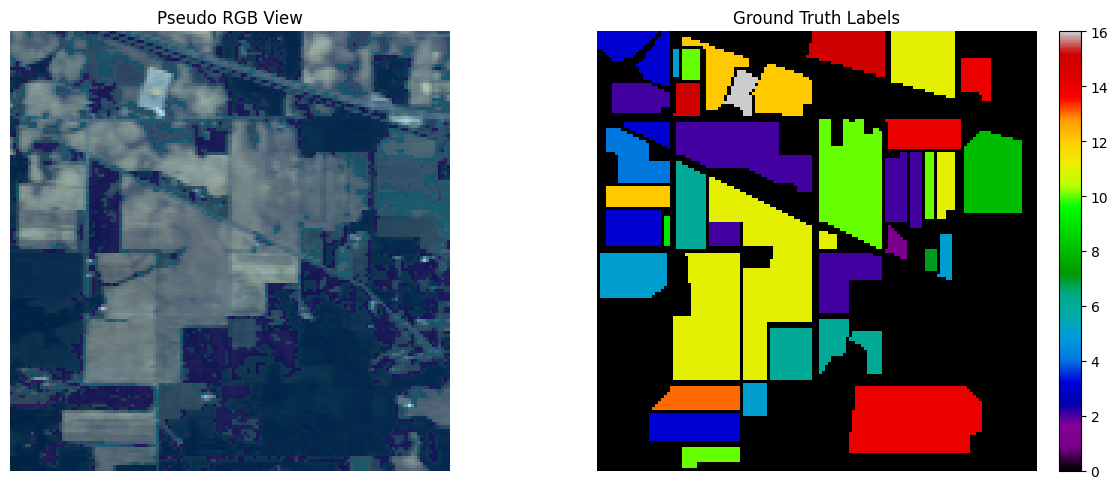

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

rgb = cube[:, :, [29, 19, 9]].astype(np.float32)
rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min() + 1e-8)
axes[0].imshow(rgb)
axes[0].set_title("Pseudo RGB View")
axes[0].axis("off")

im = axes[1].imshow(gt, cmap="nipy_spectral", vmin=0, vmax=len(class_names))
axes[1].set_title("Ground Truth Labels")
axes[1].axis("off")
plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()


## 2. 3D CNN 为什么常和 PCA 配合

原始光谱维度较高，如果全部保留，3D 卷积的计算开销会更大。
因此很多教学和实验 baseline 会先做 PCA，再把降维后的立方体输入 3D CNN。


In [5]:
PCA_COMPONENTS = 15

flat_cube = cube.reshape(-1, cube.shape[2]).astype(np.float32)
pca = PCA(n_components=PCA_COMPONENTS, whiten=True)
reduced_flat = pca.fit_transform(flat_cube).astype(np.float32)
reduced_cube = reduced_flat.reshape(cube.shape[0], cube.shape[1], PCA_COMPONENTS)

print("reduced cube shape:", reduced_cube.shape)
print("explained variance ratio sum:", float(pca.explained_variance_ratio_.sum()))


reduced cube shape: (145, 145, 15)
explained variance ratio sum: 0.9801681041717529


## 3. 划分训练 / 验证 / 测试集


In [6]:
mask = gt != 0
positions = np.argwhere(mask)
labels = gt[mask].astype(np.int64) - 1

TRAIN_RATIO = 0.1
VAL_RATIO = 0.1
TEST_RATIO = 0.8

pos_train, pos_temp, y_train, y_temp = train_test_split(
    positions,
    labels,
    train_size=TRAIN_RATIO,
    stratify=labels,
    random_state=SEED,
)

val_ratio_within_temp = VAL_RATIO / (VAL_RATIO + TEST_RATIO)
pos_val, pos_test, y_val, y_test = train_test_split(
    pos_temp,
    y_temp,
    train_size=val_ratio_within_temp,
    stratify=y_temp,
    random_state=SEED,
)

print("train samples:", len(pos_train))
print("val samples:", len(pos_val))
print("test samples:", len(pos_test))


train samples: 1024
val samples: 1025
test samples: 8200


In [7]:
def count_by_class(labels, class_names):
    values, counts = np.unique(labels, return_counts=True)
    rows = []
    for v, c in zip(values, counts):
        rows.append({"label": int(v + 1), "class_name": class_names[v], "count": int(c)})
    return pd.DataFrame(rows)


split_summary = pd.concat(
    [
        count_by_class(y_train, class_names).assign(split="train"),
        count_by_class(y_val, class_names).assign(split="val"),
        count_by_class(y_test, class_names).assign(split="test"),
    ],
    ignore_index=True,
)

split_summary.head(12)


,label,class_name,count,split
0,1,Alfalfa,5,train
1,2,Corn-notill,143,train
2,3,Corn-mintill,83,train
3,4,Corn,24,train
4,5,Grass-pasture,48,train
5,6,Grass-trees,73,train
6,7,Grass-pasture-mowed,3,train
7,8,Hay-windrowed,48,train
8,9,Oats,2,train
9,10,Soybean-notill,97,train


## 4. 标准化与三维 patch 构造

这里把每个像素的 PCA 特征标准化，再构造 `(bands, patch_h, patch_w)` 形式的三维 patch。


In [8]:
train_pixels = reduced_cube[pos_train[:, 0], pos_train[:, 1]]
scaler = StandardScaler()
scaler.fit(train_pixels)

reduced_flat_scaled = scaler.transform(reduced_cube.reshape(-1, reduced_cube.shape[2])).astype(np.float32)
reduced_cube_scaled = reduced_flat_scaled.reshape(reduced_cube.shape)

PATCH_SIZE = 9
BATCH_SIZE = 128


class PatchDataset3D(Dataset):
    def __init__(self, cube, positions, labels=None, patch_size=9):
        self.patch_size = patch_size
        self.labels = labels
        self.positions = np.asarray(positions)
        pad = patch_size // 2
        self.cube = np.pad(cube, ((pad, pad), (pad, pad), (0, 0)), mode="constant")
        self.pad = pad

    def __len__(self):
        return len(self.positions)

    def __getitem__(self, idx):
        r, c = self.positions[idx]
        rp, cp = r + self.pad, c + self.pad
        p = self.patch_size // 2
        patch = self.cube[rp - p : rp + p + 1, cp - p : cp + p + 1]
        patch = patch.transpose(2, 0, 1).astype(np.float32)
        patch = torch.from_numpy(patch).unsqueeze(0)
        if self.labels is None:
            return patch
        label = torch.tensor(int(self.labels[idx]), dtype=torch.long)
        return patch, label


train_ds = PatchDataset3D(reduced_cube_scaled, pos_train, y_train, PATCH_SIZE)
val_ds = PatchDataset3D(reduced_cube_scaled, pos_val, y_val, PATCH_SIZE)
test_ds = PatchDataset3D(reduced_cube_scaled, pos_test, y_test, PATCH_SIZE)
all_ds = PatchDataset3D(reduced_cube_scaled, positions, labels=None, patch_size=PATCH_SIZE)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)
all_loader = DataLoader(all_ds, batch_size=BATCH_SIZE, shuffle=False)

next(iter(train_loader))[0].shape


torch.Size([128, 1, 15, 9, 9])

## 5. 定义 3D CNN

这个网络使用 `Conv3d` 同时建模光谱维度和空间维度。


In [9]:
class SpectralSpatialCNN3D(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv3d(1, 8, kernel_size=(7, 3, 3), padding=(0, 1, 1)),
            nn.BatchNorm3d(8),
            nn.ReLU(inplace=True),
            nn.Conv3d(8, 16, kernel_size=(5, 3, 3), padding=(0, 1, 1)),
            nn.BatchNorm3d(16),
            nn.ReLU(inplace=True),
            nn.Conv3d(16, 24, kernel_size=(3, 3, 3), padding=(0, 0, 0)),
            nn.BatchNorm3d(24),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool3d((1, 1, 1)),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(24, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(64, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)


model = SpectralSpatialCNN3D(num_classes=len(class_names)).to(device)
model


SpectralSpatialCNN3D(
  (features): Sequential(
    (0): Conv3d(1, 8, kernel_size=(7, 3, 3), stride=(1, 1, 1), padding=(0, 1, 1))
    (1): BatchNorm3d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv3d(8, 16, kernel_size=(5, 3, 3), stride=(1, 1, 1), padding=(0, 1, 1))
    (4): BatchNorm3d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): Conv3d(16, 24, kernel_size=(3, 3, 3), stride=(1, 1, 1))
    (7): BatchNorm3d(24, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): AdaptiveAvgPool3d(output_size=(1, 1, 1))
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=24, out_features=64, bias=True)
    (2): ReLU(inplace=True)
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=64, out_features=16, bias=True)
  )
)

In [10]:
@torch.no_grad()
def evaluate_model(model, data_loader, device):
    model.eval()
    all_preds = []
    all_targets = []
    total_correct = 0
    total_count = 0

    for batch in data_loader:
        xb, yb = batch
        xb = xb.to(device)
        yb = yb.to(device)
        logits = model(xb)
        preds = logits.argmax(dim=1)
        total_correct += (preds == yb).sum().item()
        total_count += yb.size(0)
        all_preds.append(preds.cpu().numpy())
        all_targets.append(yb.cpu().numpy())

    acc = total_correct / total_count
    y_true = np.concatenate(all_targets)
    y_pred = np.concatenate(all_preds)
    return acc, y_true, y_pred


criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
EPOCHS = 10

history = {
    "train_loss": [],
    "train_acc": [],
    "val_acc": [],
}


## 6. 训练模型


In [11]:
best_state = None
best_val_acc = -1.0

for epoch in range(1, EPOCHS + 1):
    model.train()
    running_loss = 0.0
    running_correct = 0
    running_total = 0

    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * yb.size(0)
        running_correct += (logits.argmax(dim=1) == yb).sum().item()
        running_total += yb.size(0)

    train_loss = running_loss / running_total
    train_acc = running_correct / running_total
    val_acc, _, _ = evaluate_model(model, val_loader, device)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    if val_acc >= best_val_acc:
        best_val_acc = val_acc
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"loss={train_loss:.4f} | train_acc={train_acc:.4f} | val_acc={val_acc:.4f}"
    )

print("best_val_acc =", round(best_val_acc, 4))


Epoch 01/10 | loss=2.7148 | train_acc=0.1289 | val_acc=0.1395
Epoch 02/10 | loss=2.5413 | train_acc=0.3672 | val_acc=0.4732
Epoch 03/10 | loss=2.3568 | train_acc=0.4492 | val_acc=0.4907


Epoch 04/10 | loss=2.1877 | train_acc=0.4766 | val_acc=0.5220
Epoch 05/10 | loss=2.0204 | train_acc=0.4912 | val_acc=0.5161


Epoch 06/10 | loss=1.8505 | train_acc=0.5068 | val_acc=0.5288
Epoch 07/10 | loss=1.6811 | train_acc=0.5283 | val_acc=0.5337


Epoch 08/10 | loss=1.5631 | train_acc=0.5459 | val_acc=0.5493


Epoch 09/10 | loss=1.4416 | train_acc=0.5605 | val_acc=0.5795


Epoch 10/10 | loss=1.3518 | train_acc=0.5859 | val_acc=0.5951
best_val_acc = 0.5951


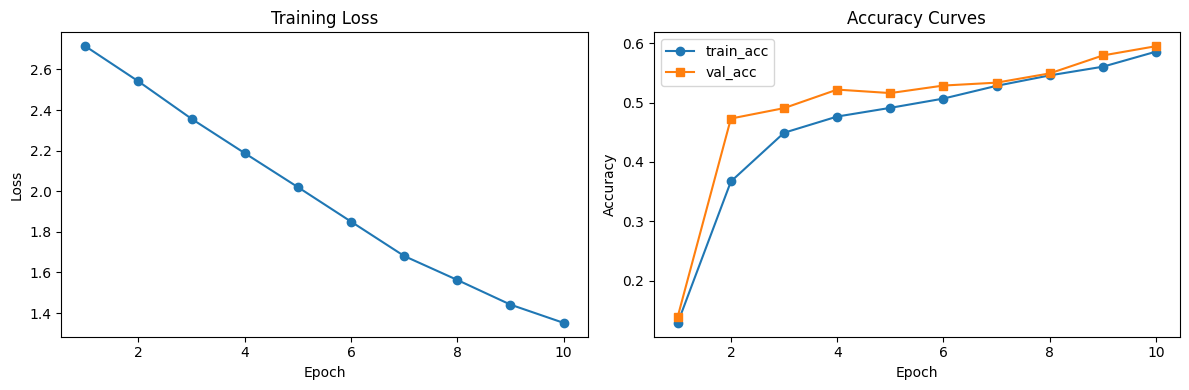

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

epoch_index = np.arange(1, EPOCHS + 1)
axes[0].plot(epoch_index, history["train_loss"], marker="o")
axes[0].set_title("Training Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")

axes[1].plot(epoch_index, history["train_acc"], marker="o", label="train_acc")
axes[1].plot(epoch_index, history["val_acc"], marker="s", label="val_acc")
axes[1].set_title("Accuracy Curves")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()


## 7. 测试集评估


In [13]:
model.load_state_dict(best_state)
model.to(device)

test_acc, y_true_test, y_pred_test = evaluate_model(model, test_loader, device)
oa = accuracy_score(y_true_test, y_pred_test)
aa = recall_score(y_true_test, y_pred_test, average="macro", zero_division=0)
kappa = cohen_kappa_score(y_true_test, y_pred_test)

print("Test accuracy:", round(test_acc, 4))
print("OA:", round(oa, 4))
print("AA:", round(aa, 4))
print("Kappa:", round(kappa, 4))


Test accuracy: 0.6129
OA: 0.6129
AA: 0.3481
Kappa: 0.5356


In [14]:
report = classification_report(
    y_true_test,
    y_pred_test,
    target_names=class_names,
    digits=4,
    zero_division=0,
)
print(report)


                              precision    recall  f1-score   support

                     Alfalfa     0.0000    0.0000    0.0000        37
                 Corn-notill     0.5417    0.5919    0.5657      1142
                Corn-mintill     0.0000    0.0000    0.0000       664
                        Corn     0.0000    0.0000    0.0000       189
               Grass-pasture     0.7570    0.7726    0.7647       387
                 Grass-trees     0.9762    0.9846    0.9804       584
         Grass-pasture-mowed     0.0000    0.0000    0.0000        22
               Hay-windrowed     0.9052    1.0000    0.9502       382
                        Oats     0.0000    0.0000    0.0000        16
              Soybean-notill     0.7638    0.2661    0.3947       778
             Soybean-mintill     0.5011    0.9542    0.6571      1965
               Soybean-clean     0.0000    0.0000    0.0000       475
                       Wheat     0.0000    0.0000    0.0000       164
                   

## 8. 整图预测


In [15]:
@torch.no_grad()
def predict_all(model, data_loader):
    model.eval()
    preds = []
    for xb in data_loader:
        xb = xb.to(device)
        logits = model(xb)
        preds.append(logits.argmax(dim=1).cpu().numpy())
    return np.concatenate(preds)


all_pred = predict_all(model, all_loader)
pred_map = np.zeros_like(gt)
pred_map[positions[:, 0], positions[:, 1]] = all_pred + 1

print("pred_map shape:", pred_map.shape)
print("nonzero predictions:", int((pred_map != 0).sum()))


pred_map shape: (145, 145)
nonzero predictions: 10249


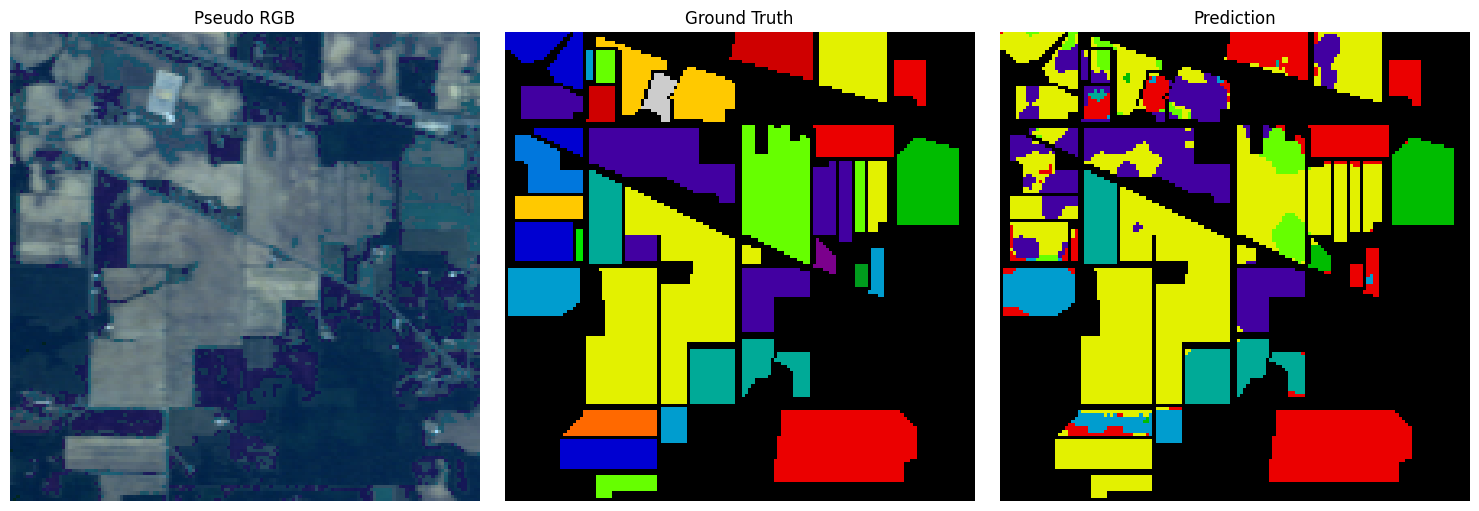

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(rgb)
axes[0].set_title("Pseudo RGB")
axes[0].axis("off")

axes[1].imshow(gt, cmap="nipy_spectral", vmin=0, vmax=len(class_names))
axes[1].set_title("Ground Truth")
axes[1].axis("off")

axes[2].imshow(pred_map, cmap="nipy_spectral", vmin=0, vmax=len(class_names))
axes[2].set_title("Prediction")
axes[2].axis("off")

plt.tight_layout()
plt.show()


## 9. 保存结果


In [17]:
output_dir = Path("results/3dcnn/IP_notebook")
output_dir.mkdir(parents=True, exist_ok=True)

metrics = {
    "seed": SEED,
    "train_ratio": TRAIN_RATIO,
    "val_ratio": VAL_RATIO,
    "test_ratio": TEST_RATIO,
    "epochs": EPOCHS,
    "batch_size": BATCH_SIZE,
    "oa": float(oa),
    "aa": float(aa),
    "kappa": float(kappa),
    "best_val_acc": float(best_val_acc),
}

(output_dir / "metrics.json").write_text(json.dumps(metrics, indent=2), encoding="utf-8")
(output_dir / "classification_report.txt").write_text(report, encoding="utf-8")
split_summary.to_csv(output_dir / "split_summary.csv", index=False)
class_count_df.to_csv(output_dir / "class_distribution.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(np.arange(1, EPOCHS + 1), history["train_loss"], marker="o")
axes[0].set_title("Training Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[1].plot(np.arange(1, EPOCHS + 1), history["train_acc"], marker="o", label="train_acc")
axes[1].plot(np.arange(1, EPOCHS + 1), history["val_acc"], marker="s", label="val_acc")
axes[1].set_title("Accuracy Curves")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
plt.tight_layout()
fig.savefig(output_dir / "training_curves.png", dpi=200)
plt.close(fig)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(gt, cmap="nipy_spectral", vmin=0, vmax=len(class_names))
axes[0].set_title("Ground Truth")
axes[0].axis("off")
axes[1].imshow(pred_map, cmap="nipy_spectral", vmin=0, vmax=len(class_names))
axes[1].set_title("Prediction")
axes[1].axis("off")
plt.tight_layout()
fig.savefig(output_dir / "prediction_map.png", dpi=200)
plt.close(fig)

print("saved to", output_dir)
print(sorted(p.name for p in output_dir.iterdir()))


saved to results\3dcnn\IP_notebook
['class_distribution.csv', 'classification_report.txt', 'metrics.json', 'prediction_map.png', 'split_summary.csv', 'training_curves.png']


## 10. 小结

3D CNN 的优势是能够直接联合建模：

- 光谱维度上的连续变化
- 空间邻域中的局部结构

这也是它在高光谱分类里长期常见的原因之一。
